In [37]:
import os, yaml, sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch
import networkx as nx
from scipy import stats

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]

for path_key in ["src_path", "useful_stuff_path"]:
    if path_key in paths and paths[path_key] not in sys.path:
        sys.path.append(paths[path_key])


In [38]:
from dataclasses import dataclass

@dataclass
class Cfg:
    brain_area: str = "AIT"
    new_fs: int = 100
    k: int = 1
    metrics: tuple = ("euclidean", "cosine_cnt", "magnitude_diff", "correlation")
    sessions: tuple = (
        ("paul", "230204"),
        ("baby1", "220226to527"),
        ("three0", "250313"),
        ("red", "220227"),
        ("octavius", "220227to405"),
        ("baby1", "240816to26"),
    )
    results_dir: Path = Path(paths["data_path"]) / "results"
    node_colors: tuple = ("midnightblue", "blue", "steelblue", "lightskyblue")
    jitter: float = 0.01
    jitter_seed: int = 0
    ttest_alpha: float = 0.05

cfg = Cfg()
cfg


Cfg(brain_area='AIT', new_fs=100, k=1, metrics=('euclidean', 'cosine_cnt', 'magnitude_diff', 'correlation'), sessions=(('paul', '230204'), ('baby1', '220226to527'), ('three0', '250313'), ('red', '220227'), ('octavius', '220227to405'), ('baby1', '240816to26')), results_dir=PosixPath('/Users/tizianocausin/metrics_II_local/results'), node_colors=('midnightblue', 'blue', 'steelblue', 'lightskyblue'), jitter=0.01, jitter_seed=0, ttest_alpha=0.05)

In [39]:
def metric_comparison_fn(metric_from, metric_to, monkey_name, date, brain_area=None, k=None):
    brain_area = cfg.brain_area if brain_area is None else brain_area
    k = cfg.k if k is None else k
    return cfg.results_dir / (
        f"metric_comparison_k{k}_{metric_from}-{metric_to}_"
        f"{monkey_name}_{date}_{brain_area}_{cfg.new_fs}Hz.npz"
    )


def load_metric_comparison(metric_from, metric_to, monkey_name, date, brain_area=None, k=None):
    fn = metric_comparison_fn(metric_from, metric_to, monkey_name, date, brain_area, k)
    if not fn.exists():
        raise FileNotFoundError(fn)
    return np.load(fn)["arr_0"]


def metric_informativeness(ii_timecourse, target_metric, comparing_metric):
    if comparing_metric != "magnitude_diff" and target_metric != "magnitude_diff":
        return 1.0 - float(np.nanmax(ii_timecourse))
    return 1.0 - float(np.nanmin(ii_timecourse))


def build_metric_graph(monkey_name, date, brain_area=None, k=None):
    G = nx.DiGraph()
    G.add_nodes_from(cfg.metrics)
    missing = []

    for target_metric in cfg.metrics:
        for comparing_metric in cfg.metrics:
            if target_metric == comparing_metric:
                continue
            try:
                ii = load_metric_comparison(target_metric, comparing_metric, monkey_name, date, brain_area, k)
            except FileNotFoundError as err:
                missing.append(Path(err.filename))
                continue
            G.add_edge(
                target_metric,
                comparing_metric,
                weight=metric_informativeness(ii, target_metric, comparing_metric),
                ii_min=float(np.nanmin(ii)),
                ii_max=float(np.nanmax(ii)),
            )

    if missing:
        for fn in missing:
            print(f"missing: {fn}")
        raise FileNotFoundError(f"Missing {len(missing)} metric-comparison files for {monkey_name} {date}")
    return G


def build_session_graphs():
    session_graphs = []
    for monkey_name, date in cfg.sessions:
        session_graphs.append(
            {
                "monkey_name": monkey_name,
                "date": date,
                "label": f"{monkey_name} {date}",
                "graph": build_metric_graph(monkey_name, date),
            }
        )
    return session_graphs


session_graphs = build_session_graphs()
print(f"loaded {len(session_graphs)} sessions from {cfg.results_dir}")


loaded 6 sessions from /Users/tizianocausin/metrics_II_local/results


In [40]:
def get_label_color(color):
    rgb = mcolors.to_rgb(color)
    r, g, b = rgb
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "white" if luminance < 0.5 else "black"


def draw_parallel_bidirectional_edge(
    ax,
    p0,
    p1,
    w01,
    w10,
    color="black",
    alpha=0.5,
    lw=5,
    arrow_scale=22,
    separation=0.01,
    node_radius=0.12,
    margin=0.02,
    wiggle=0.0,
):
    p0 = np.asarray(p0, dtype=float)
    p1 = np.asarray(p1, dtype=float)
    vec = p1 - p0
    total_length = np.linalg.norm(vec)
    if total_length == 0:
        return

    direction = vec / total_length
    perp = np.array([-direction[1], direction[0]])
    usable_length = max(total_length - 2 * node_radius - 2 * margin, 0.0)
    center_segment_start = p0 + direction * (node_radius + margin)
    center_segment_end = p1 - direction * (node_radius + margin)
    mid = (center_segment_start + center_segment_end) / 2

    def add_arrow(weight, sign):
        if weight <= 0 or usable_length <= 0:
            return
        factor = np.clip(weight, 0.01, 1.0)
        half_len = factor * usable_length / 2
        start = mid - sign * direction * half_len
        end = mid + sign * direction * half_len
        offset = (sign * separation + wiggle) * perp
        ax.add_patch(
            FancyArrowPatch(
                start + offset,
                end + offset,
                arrowstyle="-|>",
                mutation_scale=arrow_scale,
                linewidth=lw,
                color=color,
                alpha=alpha,
                shrinkA=0,
                shrinkB=0,
                zorder=2,
            )
        )

    add_arrow(w01, 1)
    add_arrow(w10, -1)


def draw_metric_nodes(ax, G, pos):
    colors = list(cfg.node_colors)
    label_colors = {node: get_label_color(color) for node, color in zip(G.nodes(), colors)}
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=20000, ax=ax)
    for node, (x, y) in pos.items():
        ax.text(
            x,
            y,
            node.replace("_", "\n"),
            color=label_colors[node],
            fontsize=18,
            fontweight="bold",
            ha="center",
            va="center",
            zorder=3,
        )


def compute_direction_ttests(session_graphs):
    ttest_results = {}
    for i, u in enumerate(cfg.metrics):
        for v in cfg.metrics[i + 1:]:
            uv = []
            vu = []
            for session in session_graphs:
                G = session["graph"]
                if G.has_edge(u, v) and G.has_edge(v, u):
                    uv.append(G[u][v]["weight"])
                    vu.append(G[v][u]["weight"])
            uv = np.asarray(uv, dtype=float)
            vu = np.asarray(vu, dtype=float)
            if len(uv) < 2:
                t_stat, p_value = np.nan, np.nan
            else:
                t_stat, p_value = stats.ttest_rel(uv, vu, nan_policy="omit")
            ttest_results[(u, v)] = {
                "t_stat": float(t_stat),
                "p_value": float(p_value),
                "mean_uv": float(np.nanmean(uv)) if len(uv) else np.nan,
                "mean_vu": float(np.nanmean(vu)) if len(vu) else np.nan,
                "n": int(len(uv)),
            }
    return ttest_results


def annotate_significant_pairs(ax, pos, ttest_results, alpha=None):
    alpha = cfg.ttest_alpha if alpha is None else alpha
    for (u, v), result in ttest_results.items():
        p_value = result["p_value"]
        if not np.isfinite(p_value) or p_value >= alpha:
            continue

        p0 = np.asarray(pos[u], dtype=float)
        p1 = np.asarray(pos[v], dtype=float)
        mid = (p0 + p1) / 2
        vec = p1 - p0
        total_length = np.linalg.norm(vec)
        if total_length == 0:
            continue
        perp = np.array([-vec[1], vec[0]]) / total_length
        outward = mid / np.linalg.norm(mid) if np.linalg.norm(mid) > 0 else perp
        star_pos = mid + 0.085 * outward + 0.025 * perp
        ax.text(
            star_pos[0],
            star_pos[1],
            "*",
            color="black",
            fontsize=34,
            fontweight="bold",
            ha="center",
            va="center",
            zorder=4,
        )


def draw_session_metric_graphs(session_graphs, title=None, ttest_results=None):
    fig, ax = plt.subplots(figsize=(12, 12))

    base_graph = nx.DiGraph()
    base_graph.add_nodes_from(cfg.metrics)
    pos = nx.circular_layout(base_graph)
    pos = {node: 0.5 * coord for node, coord in pos.items()}
    draw_metric_nodes(ax, base_graph, pos)

    rng = np.random.default_rng(cfg.jitter_seed)
    for session in session_graphs:
        G = session["graph"]
        wig = rng.uniform(-cfg.jitter, cfg.jitter)
        drawn_pairs = set()

        for u, v in G.edges():
            pair = tuple(sorted([u, v]))
            if pair in drawn_pairs:
                continue
            drawn_pairs.add(pair)

            w_uv = G[u][v]["weight"] if G.has_edge(u, v) else 0
            w_vu = G[v][u]["weight"] if G.has_edge(v, u) else 0
            total = w_uv + w_vu
            if total <= 0:
                continue

            draw_parallel_bidirectional_edge(
                ax,
                pos[u],
                pos[v],
                (w_uv / total) ** 1,
                (w_vu / total) ** 1,
                color="black",
                node_radius=0.0075,
                wiggle=wig,
                alpha=0.5,
                separation=0.03,
                lw=5,
            )

    if ttest_results is None:
        ttest_results = compute_direction_ttests(session_graphs)
    annotate_significant_pairs(ax, pos, ttest_results)

    ax.set_aspect("equal")
    ax.axis("off")
    ax.margins(0.22)
    if title is not None:
        ax.set_title(title, fontsize=18, pad=20)
    plt.tight_layout()
    return fig, ax


euclidean -> cosine_cnt vs cosine_cnt -> euclidean: t=2.907, p=0.03351, n=6 *
euclidean -> magnitude_diff vs magnitude_diff -> euclidean: t=1.199, p=0.2841, n=6
euclidean -> correlation vs correlation -> euclidean: t=4.733, p=0.005181, n=6 *
cosine_cnt -> magnitude_diff vs magnitude_diff -> cosine_cnt: t=1.497, p=0.1947, n=6
cosine_cnt -> correlation vs correlation -> cosine_cnt: t=3.188, p=0.02431, n=6 *
magnitude_diff -> correlation vs correlation -> magnitude_diff: t=-0.591, p=0.5801, n=6


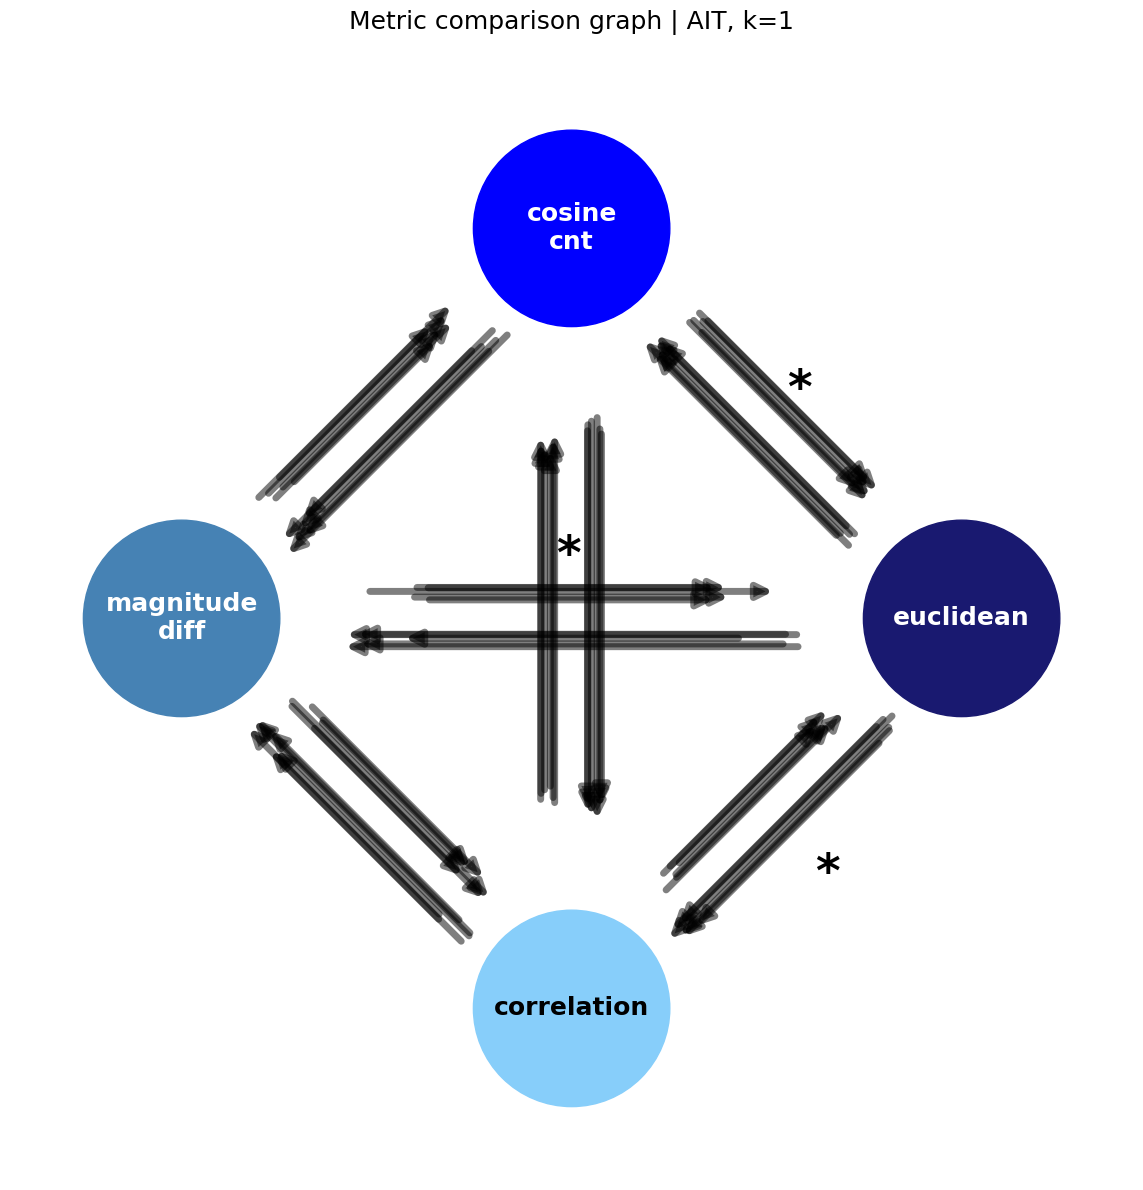

In [41]:
session_graphs = build_session_graphs()
ttest_results = compute_direction_ttests(session_graphs)
for (u, v), result in ttest_results.items():
    marker = " *" if np.isfinite(result["p_value"]) and result["p_value"] < cfg.ttest_alpha else ""
    print(
        f"{u} -> {v} vs {v} -> {u}: "
        f"t={result['t_stat']:.3f}, p={result['p_value']:.4g}, n={result['n']}" + marker
    )

fig, ax = draw_session_metric_graphs(
    session_graphs,
    title=f"Metric comparison graph | {cfg.brain_area}, k={cfg.k}",
    ttest_results=ttest_results,
)
plt.show()
